In [1]:
# Setup. Reuse the arrays already in memory, or rebuild if starting a fresh kernel.
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, "..")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.config import RESULTS_DIR
from src.data import IMAGINED_RUNS, EXECUTED_RUNS
from src.preprocess import build_dataset, EXCLUDED_SUBJECTS
from src.models import csp_lda
from src.evaluate import tier_a, tier_b, tier_c, summarize

ALL_SUBJECTS = [s for s in range(1, 110) if s not in EXCLUDED_SUBJECTS]
X, y, subjects, runs = build_dataset(ALL_SUBJECTS, IMAGINED_RUNS)
X = X.astype(np.float32)

In [2]:
# Sanity fit on one subject before spending ten minutes on the full harness.
m = subjects == 1
model = csp_lda()
model.fit(X[m], y[m])
print("train accuracy (expect high, this is not a result):", model.score(X[m], y[m]))

Computing rank from data with rank=None
    Using tolerance 0.00021 (2.2e-16 eps * 64 dim * 1.5e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
train accuracy (expect high, this is not a result): 1.0


In [3]:
# The three tiers. Tier C is the slow one.
a = tier_a(csp_lda, X, y, subjects)
b = tier_b(csp_lda, X, y, subjects, runs)
c = tier_c(csp_lda, X, y, subjects)

table = pd.DataFrame([
    summarize(a, "A: random split"),
    summarize(b, "B: within-subject"),
    summarize(c, "C: new subject"),
])
table.to_csv(RESULTS_DIR / "tier_table.csv", index=False)
print(table.to_string(index=False))

Computing rank from data with rank=None
    Using tolerance 0.0018 (2.2e-16 eps * 64 dim * 1.3e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.0018 (2.2e-16 eps * 64 dim * 1.3e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.0018 (2.2e-16 eps * 64 dim * 1.3e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRI

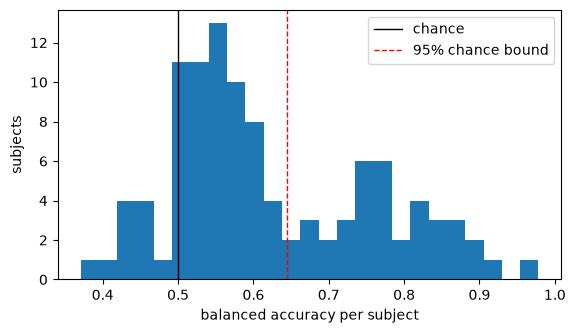

In [4]:
# Per-subject spread under Tier C. The mean hides the interesting part.
c.to_csv(RESULTS_DIR / "tier_c_per_subject.csv", index=False)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(c.acc, bins=25)
ax.axvline(0.5, color="k", lw=1, label="chance")
ax.axvline(c.chance_95.mean(), color="r", ls="--", lw=1, label="95% chance bound")
ax.set_xlabel("balanced accuracy per subject")
ax.set_ylabel("subjects")
ax.legend()
fig.savefig(RESULTS_DIR / "tier_c_distribution.png", dpi=150, bbox_inches="tight")